# The Score Matching Technique

In this notebook, we provide an example of the score matching technique in the context of generative models.

## Details of Score Matching

Consider a probability distribution $\mu$ on $\mathbb{R}^d$, with density (likelihood) $p_\mu(x)$. The score function is defined as $s_\mu(x) = \nabla_x \log p_\mu(x)$ (which is in the context of generative modelling, different from the "score function" in statistics theory). The score function encodes the information of the measure $\mu$ and it turns out that one can easily sample from $\mu$ using the score function through the Langevin Monte Carlo (LMC). Therefore, learning the measure $\mu$ is equivalent to learning the score $s_\mu$.

LMC consists of the following procedures: sampling $X_0$ from any fixed initial distribution and solving the diffusion
$$dX_t = \frac{1}{2}s_\mu(X_t)\,dt + dW_t.$$
It's guaranteed that the law of $X_t$ converges to $\mu$ as $t\to\infty$ (MCMC). In practice, we simulate the Langevin diffusion numerically:
$$X_{t+h} = X_t + \frac{1}{2}s_\mu(X_t)h + \sqrt{h}\xi_t,\ \xi_t\sim N(0,1)$$
for $t\in[0,T]$ where $T$ is large, and use the empirical distribution of $X_T$ as an approximation for $\mu$.

Training of the score function: through NN. Let $\Sigma_\phi$ denote the score function approximated by the NN with parameters $\phi$, then we wish to minimize the residual:
$$\mathbb{E}_{X\sim\mu} ||\Sigma_\phi(X) - s_\mu(X)||_2^2\propto \mathbb{E}_{X\sim\mu} \left(Tr(\nabla_x\Sigma_\phi(X)) + \frac{1}{2}||\Sigma_\phi(X)||_2^2\right)$$
which does not contain the unknown score function $s_\mu$. With this important observation, we can form the loss as the asynchronous form:
$$L(\phi) = Tr(\nabla_x\Sigma_\phi(X_{t_n})) + \frac{1}{2}||\Sigma_\phi(X_{t_n})||_2^2$$
for some sample $X_{t_n}$ we have observed (a batched version of the loss is also possible to use).

In [1]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.neighbors import KernelDensity
import matplotlib.pyplot as plt

In [2]:
class _MLP(nn.Module):
    """
    Simple multi-layer perceptron with a variable number of hidden layers.
    """
    def __init__(self, layer_sizes: list[int], hidden_activation: nn.modules.activation, output_activation: nn.modules.activation = None):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layer_sizes) - 1):
            self.layers.append(nn.Linear(layer_sizes[i], layer_sizes[i + 1]))
            if i != len(layer_sizes) - 2:
                self.layers.append(hidden_activation)
        if output_activation is not None:
            self.layers.append(output_activation)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for layer in self.layers:
            x = layer(x)
        return x

In [3]:
class ScoreNet(nn.Module):
    """Encapsulates the score network and its training."""
    def __init__(self, layer_sizes: list[int], activation: nn.modules.activation, lr: float):
        super().__init__()
        assert layer_sizes[0] == layer_sizes[-1], 'First and last layer must have same size'
        self.model = _MLP(layer_sizes, activation)
        self.state_dim = layer_sizes[0] # Record state dimension
        # Adam optimizer
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

    def train_on_batch(self, batch: torch.Tensor):
        """Train the score model on a batch using the score matching objective."""
        '''batch has size N_batch * state_dim'''
        
        batch.requires_grad = True
        score = self.model(batch) # Forward prop to calculate \Sigma(X_{t_n})
        score_sum = torch.sum(score,dim=0) # Sum w.r.t. all samples in the batch
        
        # Derive Tr(\nabla_x\Sigma) evaluated at X_{t_n}, through autograd
        # Calculate \partial_{x^i}\Sigma_i for each i in {1,2,...,d}
        trace_score_dx = torch.tensor(0.0)
        score_dx_lst = ([torch.autograd.grad(score_sum[i], batch, create_graph=True)[0][:,i]
                    for i in range(self.state_dim)])
        for i in range(self.state_dim):
            trace_score_dx = trace_score_dx + torch.sum(score_dx_lst[i])
        
        # Loss
        loss = trace_score_dx + 0.5 * torch.sum(score ** 2)
        loss = loss / batch.shape[0] # Scale the loss
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        batch.requires_grad = False

    @torch.no_grad()
    def generate_samples(self, n_steps: int, step_size: float, n_samples: int, x_init: torch.Tensor = None):
        """Generate samples from the score function using Langevin dynamics."""
        if x_init is None:
            x = torch.randn(n_samples, self.state_dim) # By default standard Gaussian init in LMC
        else:
            assert x_init.shape[0] == n_samples, f'x_init must have shape (n_samples, STATE_DIM), got {x_init.shape}'
            assert x_init.shape[1] == self.state_dim, f'x_init must have shape (n_samples, STATE_DIM), got {x_init.shape}'
            x = x_init
        
        # Simulate Langevin diffusion (n_steps denotes the length of time horizon)
        for _ in range(n_steps):
            score = self.model(x)
            x = x + 0.5 * step_size * score + torch.randn_like(x) * torch.sqrt(torch.tensor(step_size))
        return x

## Test: one-dimensional case

In the first test case, the measure $\mu = N(10,4)$ so $s_\mu(x) = -\frac{1}{4}(x-10)$.

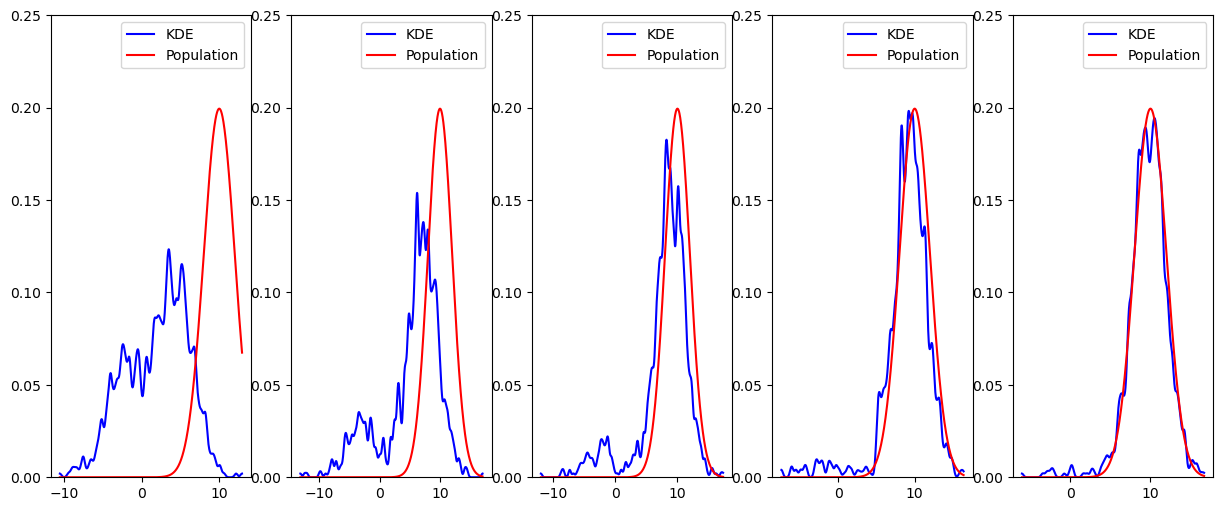

In [4]:
# Test on real line
STATE_DIM = 1
BATCH_SIZE = 10
score_lr = 5e-4 # lr

# Create a scorenet
score = ScoreNet([STATE_DIM, 128, STATE_DIM], torch.nn.Tanh(), score_lr)

# The population distribution
pop_dist = torch.distributions.normal.Normal(10,2)

# Number of iterations and the number of plots
N_ITER = 1000; N_PLOTS = 5; score_samples = None

fig, axes = plt.subplots(1, N_PLOTS, figsize = (15, 6))

for iter_ind in range(N_ITER):
    # Provide a batch of samples to the score network
    state = pop_dist.sample((BATCH_SIZE,STATE_DIM))
    
    # Train the net
    score.train_on_batch(state)
    
    # Per certain iterations, generate samples and compare with the population dist
    if (iter_ind + 1) % (N_ITER // N_PLOTS) == 0:
        # LMC
        score_samples = score.generate_samples(n_steps=200, step_size=5e-2, n_samples=1000, x_init=score_samples)
        
        # KDE
        kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(score_samples)
        
        # Plot KDE
        x_plot = np.linspace(min(score_samples), max(score_samples), 1000)
        kde_plot = np.exp(kde.score_samples(x_plot))
        k = (iter_ind + 1) // (N_ITER // N_PLOTS) - 1
        KDE_PLOT, = axes[k].plot(x_plot,kde_plot,color = 'b',label = 'KDE')
        
        # Plot true density
        true_density = pop_dist.log_prob(torch.Tensor(x_plot)).exp()
        TRUE_DENSITY_PLOT, = axes[k].plot(x_plot,true_density,color = 'r',label = 'Population')
        axes[k].set_ylim([0,0.25])
        axes[k].legend(loc = 'best')
        
# Show the plot
plt.show()

Then, let's plot the score function approximated by the Scorenet and compare with the population score function.

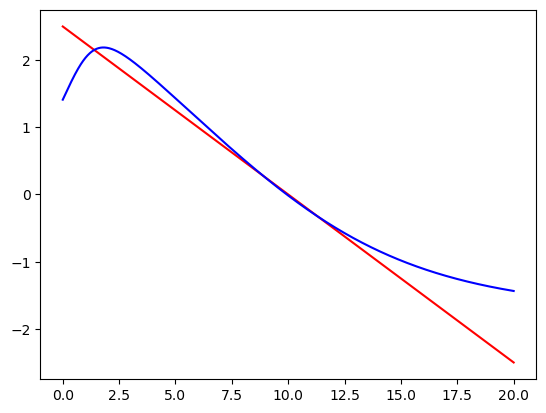

In [5]:
x_plot = np.linspace(0, 20, 1000)
true_score = -(x_plot - 10.0) / 4
with torch.no_grad():
    approx_score = score.model(torch.Tensor(x_plot).reshape(-1,1)).reshape(-1)
plt.plot(x_plot,true_score,color = 'r',label = 'True Score')
plt.plot(x_plot,approx_score,color = 'b',label = 'KDE Score')

As we can see, the KDE density gradually matches the true population density as training goes on, and the score function is well-approximated near the population mean, where most of the observations appear.

## Test: multi-dimensional Case

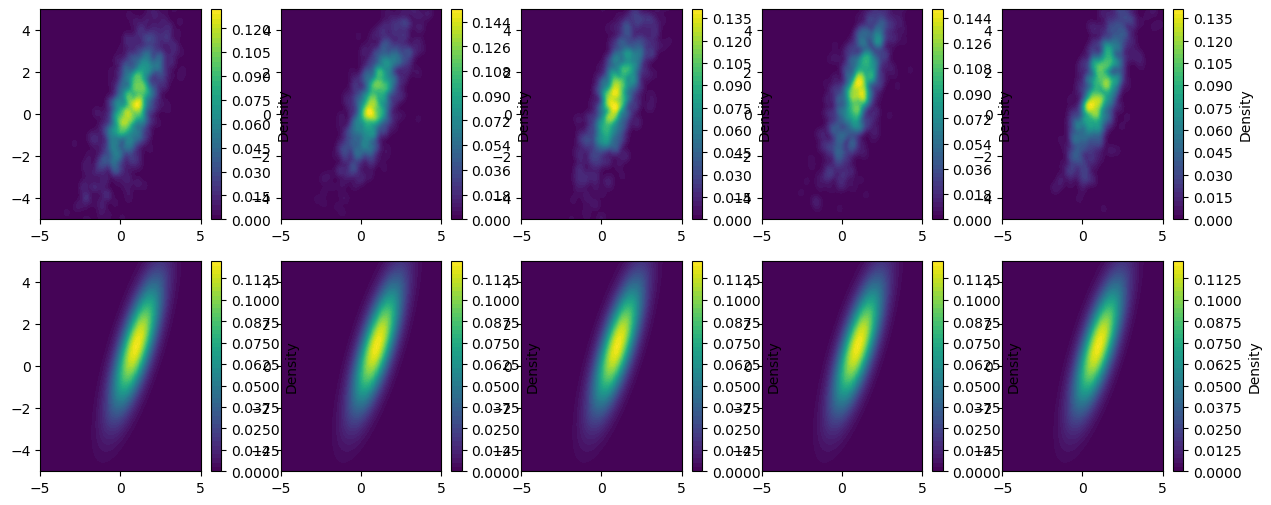

In [13]:
# Test on the plane
STATE_DIM = 2
BATCH_SIZE = 10
score_lr = 5e-4 # lr

# Create a scorenet
score = ScoreNet([STATE_DIM, 128, STATE_DIM], torch.nn.Tanh(), score_lr)

# The population distribution
mean = torch.tensor([1.0, 1.0])
cov = torch.tensor([[1.0, 1.5], [1.5, 4.0]])
pop_dist = torch.distributions.multivariate_normal.MultivariateNormal(mean, cov)

# Number of iterations and the number of plots
N_ITER = 1000; N_PLOTS = 5; score_samples = None

fig, axes = plt.subplots(2, N_PLOTS, figsize = (15, 6))

for iter_ind in range(N_ITER):
    # Provide a batch of samples to the score network
    state = pop_dist.sample(sample_shape=(BATCH_SIZE,))
    
    # Train the net
    score.train_on_batch(state)
    
    # Per certain iterations, generate samples and compare with the population dist
    if (iter_ind + 1) % (N_ITER // N_PLOTS) == 0:
        # LMC
        score_samples = score.generate_samples(n_steps=500, step_size=5e-2, n_samples=1000, x_init=score_samples)
        
        # KDE
        kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(score_samples)
        
        # Plot KDE
        x_plot = torch.linspace(-5, 5, 100)
        y_plot = torch.linspace(-5, 5, 100)
        X_plot, Y_plot = torch.meshgrid(x_plot, y_plot, indexing='ij')
        grid_plot = torch.stack([X_plot.flatten(), Y_plot.flatten()], dim=-1)
        kde_plot = np.exp(kde.score_samples(grid_plot)).reshape(100, 100)
        k = (iter_ind + 1) // (N_ITER // N_PLOTS) - 1
        KDE_PLOT = axes[0,k].contourf(X_plot.numpy(), Y_plot.numpy(), kde_plot, levels=50, cmap='viridis')
        plt.colorbar(KDE_PLOT,ax = axes[0,k],label='Density')
        
        # Plot true density
        true_density = pop_dist.log_prob(grid_plot).exp().reshape(100, 100)
        TRUE_PLOT = axes[1,k].contourf(X_plot.numpy(), Y_plot.numpy(), true_density.numpy(), levels=50, cmap='viridis')
        plt.colorbar(TRUE_PLOT,ax = axes[1,k],label='Density')
        
# Show the plot
plt.show()

## Learning a Flow of Measure

Let's test if the score matching is capable of learning a flow of measure, i.e., $\mu_t$. Instead of maintaining a scorenet at each time step, we modify the score net such that it takes the current time $t$ as input.

In [7]:
class Scorenet_t(nn.Module):
    def __init__(self,layer_sizes: list[int]):
        super().__init__()
        assert layer_sizes[0] == layer_sizes[-1] + 1, 'First and last layer size does not match!'
        assert len(layer_sizes) == 3, 'Only two layers supported!'

        self.state_dim = layer_sizes[-1] # Record state dimension
        self.linear1 = nn.Linear(layer_sizes[0], layer_sizes[1])
        self.linear2 = nn.Linear(layer_sizes[1], layer_sizes[-1])
        self.activate = nn.Tanh()
    def forward(self, t, x):
        # Time t formed as an entry
        t_vec = t * torch.ones(x.shape[0],1)
        tx = torch.cat((t_vec,x), dim=-1)
        NN_out = self.linear1(tx)
        NN_out = self.activate(NN_out)
        NN_out = self.linear2(NN_out)
        return NN_out

In [17]:
# Test on the plane
STATE_DIM = 2
BATCH_SIZE = 256
score_lr = 5e-4 # lr

# Create a scorenet
score = Scorenet_t([STATE_DIM + 1, 128, STATE_DIM])
optimizer = torch.optim.Adam(score.parameters(), lr=score_lr)

# The population distribution
base_mean = torch.tensor([-2.0, -3.0])
base_cov = torch.tensor([[1.0, 1.5], [1.5, 4.0]])

# Number of iterations and the number of plots
N_ITER = 10000; score_samples = None

# Time horizon [0,T] and the discretization
T = 0.1; N_STEPS = 5; dt = T / N_STEPS

# Build up the flow of measure
mean_flow = []; cov_flow = []; pop_flow = []
for t_ind in range(N_STEPS):
    pert = np.linspace(0,4,N_STEPS)
    # Only perturb the mean here
    mean_flow.append(base_mean + np.array([pert[t_ind],pert[t_ind]],dtype = 'float32'))
    cov_flow.append(base_cov)
    pop_flow.append(torch.distributions.multivariate_normal.MultivariateNormal(mean_flow[t_ind], cov_flow[t_ind]))

for iter_ind in range(N_ITER):
    
    loss = torch.tensor(0.0)
    for t_ind in range(N_STEPS):
        
        # Provide a batch of samples to the score network
        batch = pop_flow[t_ind].sample(sample_shape=(BATCH_SIZE,))
    
        # Train the net
        t = t_ind * dt
        batch.requires_grad = True
        batch_score = score(t,batch) # Forward prop to calculate \Sigma(X_{t_n})
        batch_score_sum = torch.sum(batch_score,dim=0) # Sum w.r.t. all samples in the batch
        
        # Derive Tr(\nabla_x\Sigma) evaluated at X_{t_n}, through autograd
        # Calculate \partial_{x^i}\Sigma_i for each i in {1,2,...,d}
        trace_score_dx = torch.tensor(0.0)
        score_dx_lst = ([torch.autograd.grad(batch_score_sum[i], batch, create_graph=True)[0][:,i]
                    for i in range(STATE_DIM)])
        for i in range(STATE_DIM):
            trace_score_dx = trace_score_dx + torch.sum(score_dx_lst[i])
        
        # Accumulate the loss across different time steps
        loss = loss + trace_score_dx + 0.5 * torch.sum(batch_score ** 2)
        
    loss = loss / (batch.shape[0] * N_STEPS) # Scale the loss
        
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    batch.requires_grad = False

In [18]:
# Generate samples at each time step
score_samples = {}
LMC_n_steps = 500; LMC_step_size = 5e-2; LMC_n_samples = 1000
for t_ind in range(N_STEPS):
    t = t_ind * dt
    with torch.no_grad():
        x = torch.randn(LMC_n_samples, STATE_DIM) # By default standard Gaussian init in LMC

        # Simulate Langevin diffusion (n_steps denotes the length of time horizon)
        for _ in range(LMC_n_steps):
            x_score = score(t,x)
            x = x + 0.5 * LMC_step_size * x_score + torch.randn_like(x) * torch.sqrt(torch.tensor(LMC_step_size))
        
    score_samples[t_ind] = x

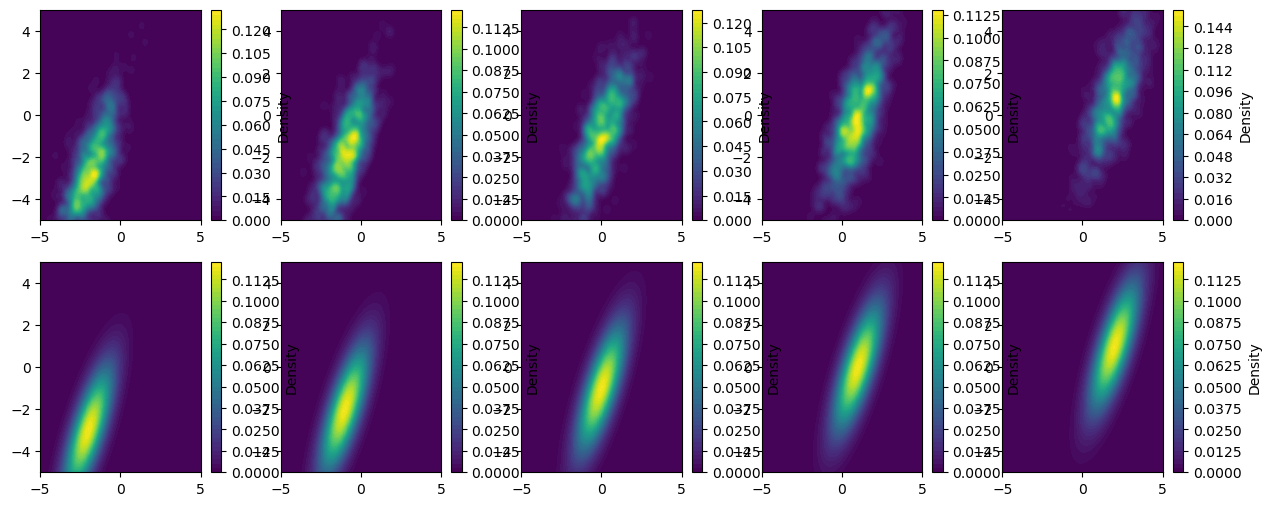

In [19]:
# Only plot at last to check the training result
fig, axes = plt.subplots(2, N_STEPS, figsize = (15, 6))

x_plot = torch.linspace(-5, 5, 100)
y_plot = torch.linspace(-5, 5, 100)
X_plot, Y_plot = torch.meshgrid(x_plot, y_plot, indexing='ij')
grid_plot = torch.stack([X_plot.flatten(), Y_plot.flatten()], dim=-1)

for t_ind in range(N_STEPS):
        
    # KDE
    kde = KernelDensity(kernel='gaussian', bandwidth=0.2).fit(score_samples[t_ind])
        
    # Plot KDE
    kde_plot = np.exp(kde.score_samples(grid_plot)).reshape(100, 100)
    KDE_PLOT = axes[0,t_ind].contourf(X_plot.numpy(), Y_plot.numpy(), kde_plot, levels=50, cmap='viridis')
    plt.colorbar(KDE_PLOT,ax = axes[0,t_ind],label='Density')
        
    # Plot true density
    true_density = pop_flow[t_ind].log_prob(grid_plot).exp().reshape(100, 100)
    TRUE_PLOT = axes[1,t_ind].contourf(X_plot.numpy(), Y_plot.numpy(), true_density.numpy(), levels=50, cmap='viridis')
    plt.colorbar(TRUE_PLOT,ax = axes[1,t_ind],label='Density')
plt.show()

Some empirical observations: 
1. Need enough number of iterations (N_ITER) to learn the change in the measure as time goes by.
2. The batch size in the training procedure does not make a big difference.
3. The LMC parameters do not make a big difference.